# Aff-Wild2 Stage 3 — S7 ablations

Reproduces every numerical row that feeds Section 6.x.5 (`tab:stage3aw2_smoothing` and the surrounding S7 narrative) of `internship_report.tex`. Each section below corresponds to one S7 item:

1. Paper-A smoothing grid on the existing F4 and `visual_only` checkpoints (no retraining).
2. F4 retrain under stronger weight decay + 3-epoch budget (addresses the epoch-1 overfit).
3. Audio-encoder ablation: HuBERT-large vs. wav2vec 2.0 base on F4 (RQ3).
4. F4 context-window ablation `window in {1, 3, 10}` (baseline = 5).
5. Three-seed replication of the F4 baseline.
6. MBF visual-backbone ablation on F4 plus the matching `visual_only` MBF control.
7. F3 gate visualisation (qualitative figure).
8. Aggregate summary table → `results/aw2_stage3_ablations/summary.md`.

Prerequisites:
* `aw2_05_stage3_fusion.ipynb` has produced `results/stage3_{visual_only,audio_only,f1_concat,f2_blend,f3_gate,f4_xattn,f5_lmf}/best.pt`.
* `aw2_04_align_audio.ipynb` has populated `cache/features/{hubert_large_aligned,wav2vec2_base_aligned}/`.
* `aw2_01_extract_visual.ipynb` has populated `cache/features/{enet_b0_8_va_mtl,mbf_va_mtl}/`.

Each section is independent; rerun only the ones whose inputs changed.

In [1]:
import json, os, subprocess, sys
from pathlib import Path

REPO = Path.cwd().resolve().parent
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

ABL = REPO / 'results' / 'aw2_stage3_ablations'
ABL.mkdir(parents=True, exist_ok=True)
RUNTIME_CFG = ABL / '_configs'
RUNTIME_CFG.mkdir(exist_ok=True)

for d in (REPO / 'cache' / 'features' / 'enet_b0_8_va_mtl',
          REPO / 'cache' / 'features' / 'hubert_large_aligned',
          REPO / 'cache' / 'features' / 'wav2vec2_base_aligned',
          REPO / 'results' / 'stage3_f4_xattn',
          REPO / 'results' / 'stage3_visual_only'):
    assert d.exists(), f'missing prerequisite path: {d}'
print('cwd          :', Path.cwd())
print('ablation out :', ABL)

cwd          : C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code
ablation out : C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\aw2_stage3_ablations


In [ ]:
def _run(cmd):
    print('$', ' '.join(map(str, cmd)))
    proc = subprocess.run(cmd, check=False)
    assert proc.returncode == 0, f'command failed (exit={proc.returncode}): {cmd}'

def run_train(config_rel):
    _run([sys.executable, '-u', '-m', 'src.train_fusion', '--config', str(config_rel)])

def run_eval(checkpoint, config_rel):
    _run([sys.executable, '-u', '-m', 'src.eval_fusion',
          '--config', str(config_rel),
          '--checkpoint', str(checkpoint)])

def run_smooth(checkpoint, config_rel, output_dir=None):
    cmd = [sys.executable, '-m', 'src.smooth_fusion',
           '--checkpoint', str(checkpoint),
           '--config', str(config_rel)]
    if output_dir is not None:
        cmd += ['--output-dir', str(output_dir)]
    _run(cmd)

def train_eval_smooth(config_rel):
    """Standard end-to-end ablation step: train, eval (raw), smooth (best grid)."""
    from omegaconf import OmegaConf
    cfg = OmegaConf.load(config_rel)
    out = REPO / cfg.output.results_dir
    run_train(config_rel)
    run_eval(out / 'best.pt', config_rel)
    run_smooth(out / 'best.pt', config_rel)
    return out

## 1. Smoothing grid on the existing F4 and `visual_only` checkpoints

Applies the Paper-A grid (`sigma in {0.1, 1, 10, 50, 100, 500, 1e3, 1e4, 1e5}` × `delta in {1, 5, 10, 50, 100}`) to the EXPR softmax probabilities and VA regressions of each cached checkpoint, leaving AU at its raw threshold-tuned best. Writes `results/stage3_<variant>/smoothing.{md,json}`. No retraining.

Expected outcome (single seed, May 2026):
* `visual_only`: raw `P_MTL@0.5 = 1.244` → smoothed `1.322` at `(sigma, delta) = (500, 10)`, `+0.078`.
* `f4_xattn` : raw `P_MTL@0.5 = 1.299` → smoothed `1.328` at `(1e5, 10)`, `+0.029`.
* Bimodal gap collapses from `+0.055` raw to `+0.007` smoothed.

In [3]:
run_smooth('results/stage3_f4_xattn/best.pt',     'configs/stage3_f4_xattn.yaml')
run_smooth('results/stage3_visual_only/best.pt',  'configs/stage3_visual_only.yaml')

$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -m src.smooth_fusion --checkpoint results/stage3_f4_xattn/best.pt --config configs/stage3_f4_xattn.yaml
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -m src.smooth_fusion --checkpoint results/stage3_visual_only/best.pt --config configs/stage3_visual_only.yaml


## 2. F4 retrain under stronger weight decay (overfit fix)

The original F4 log shows train loss `1.17 → 0.28` and val loss `3.55 → 6.14` over 15 epochs; `best.pt` always lands at epoch 1. The retrain caps epochs at 3 and lifts weight decay from `1e-4` to `1e-3`. Config: `configs/stage3_f4_xattn_wd1e3.yaml`.

In [4]:
train_eval_smooth('configs/stage3_f4_xattn_wd1e3.yaml')

$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u train_fusion.py --config configs/stage3_f4_xattn_wd1e3.yaml
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u eval_fusion.py --config configs/stage3_f4_xattn_wd1e3.yaml --checkpoint C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\stage3_f4_xattn_wd1e3\best.pt
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -m src.smooth_fusion --checkpoint C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\stage3_f4_xattn_wd1e3\best.pt --config configs/stage3_f4_xattn_wd1e3.yaml


WindowsPath('C:/Users/Andrey Lyaschenko/Documents/vkr/thesis-code/results/stage3_f4_xattn_wd1e3')

## 3. Audio-encoder ablation: HuBERT-large vs. wav2vec 2.0 base

Trains F4 with the wav2vec aligned cache (768-d) instead of HuBERT (1024-d). Same fusion hyperparameters; weight decay `1e-3` and 3 epochs to match the corrected protocol. Config: `configs/stage3_f4_xattn_wav2vec.yaml`. Directly answers RQ3.

In [5]:
train_eval_smooth('configs/stage3_f4_xattn_wav2vec.yaml')

$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u train_fusion.py --config configs/stage3_f4_xattn_wav2vec.yaml
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u eval_fusion.py --config configs/stage3_f4_xattn_wav2vec.yaml --checkpoint C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\stage3_f4_xattn_wav2vec\best.pt
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -m src.smooth_fusion --checkpoint C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\stage3_f4_xattn_wav2vec\best.pt --config configs/stage3_f4_xattn_wav2vec.yaml


WindowsPath('C:/Users/Andrey Lyaschenko/Documents/vkr/thesis-code/results/stage3_f4_xattn_wav2vec')

## 4. F4 context-window ablation

Sweeps `fusion.window in {1, 3, 10}` (baseline = 5). The smoothing result in Section 1 suggested F4's cross-attention is partly substituting for temporal smoothing; this ablation tests whether shrinking the window collapses F4 toward the per-frame variants and whether enlarging it helps further.

In [6]:
for w in (1, 3, 10):
    train_eval_smooth(f'configs/stage3_f4_xattn_w{w}.yaml')

$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u train_fusion.py --config configs/stage3_f4_xattn_w1.yaml
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u eval_fusion.py --config configs/stage3_f4_xattn_w1.yaml --checkpoint C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\stage3_f4_xattn_w1\best.pt
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -m src.smooth_fusion --checkpoint C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\stage3_f4_xattn_w1\best.pt --config configs/stage3_f4_xattn_w1.yaml
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u train_fusion.py --config configs/stage3_f4_xattn_w3.yaml
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u eval_fusion.py --config configs/stage3_f4_xattn_w3.yaml --checkpoint C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\stage3_f4_xattn_w3\best.pt
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\

## 5. Three-seed replication of F4 (defence-time hardening)

Re-runs the **stronger-WD** F4 protocol (`configs/stage3_f4_xattn_wd1e3.yaml`) at seeds 0, 1, 2. Each seed gets its own runtime config under `results/aw2_stage3_ablations/_configs/` and its own results directory. Lets us put mean ± s.d. on `tab:stage3aw2_delivered`.

In [7]:
from omegaconf import OmegaConf

BASE_CFG = REPO / 'configs' / 'stage3_f4_xattn_wd1e3.yaml'
for seed in (0, 1, 2):
    cfg = OmegaConf.load(BASE_CFG)
    cfg.seed = seed
    cfg.run_name = f'stage3_f4_xattn_seed{seed}'
    cfg.output.results_dir = f'results/stage3_f4_xattn_seed{seed}'
    out_cfg = RUNTIME_CFG / f'stage3_f4_xattn_seed{seed}.yaml'
    OmegaConf.save(cfg, out_cfg)
    train_eval_smooth(out_cfg.relative_to(REPO).as_posix())

$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u train_fusion.py --config results/aw2_stage3_ablations/_configs/stage3_f4_xattn_seed0.yaml
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u eval_fusion.py --config results/aw2_stage3_ablations/_configs/stage3_f4_xattn_seed0.yaml --checkpoint C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\stage3_f4_xattn_seed0\best.pt
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -m src.smooth_fusion --checkpoint C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\stage3_f4_xattn_seed0\best.pt --config results/aw2_stage3_ablations/_configs/stage3_f4_xattn_seed0.yaml
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u train_fusion.py --config results/aw2_stage3_ablations/_configs/stage3_f4_xattn_seed1.yaml
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u eval_fusion.py --config results/aw2_stage3_ablations/_configs/stage3_f4_xatt

## 6. MBF visual-backbone ablation on F4

Two-step:
1. **Re-align audio to MBF's per-video frame timeline.** The HuBERT raw cache was extracted per source video (frame-rate-independent), but `align_audio_to_video.py` interpolates onto the visual cache's `T_video`. If MBF and `enet` selected the same `image_names` for each video this is redundant, but in the general case the MBF cache may have a different frame count per video, so we materialise a matching aligned cache `cache/features/hubert_large_aligned_mbf/` once.
2. **Train F4 + visual-only MBF control** with `configs/stage3_f4_xattn_mbf.yaml` and `configs/stage3_visual_only_mbf.yaml`. Both pull from `cache/features/mbf_va_mtl/` for the visual side and `…_aligned_mbf/` for the audio side.

In [8]:
from src.features.align_audio_to_video import align_caches

MBF_VISUAL = REPO / 'cache' / 'features' / 'mbf_va_mtl'
HUBERT_RAW = REPO / 'cache' / 'features' / 'hubert_large'
HUBERT_MBF_ALIGNED = REPO / 'cache' / 'features' / 'hubert_large_aligned_mbf'

assert MBF_VISUAL.exists(), f'missing MBF visual cache: {MBF_VISUAL} (run aw2_01_extract_visual.ipynb on the mbf backbone)'
assert HUBERT_RAW.exists(), f'missing raw HuBERT cache: {HUBERT_RAW}'

HUBERT_MBF_ALIGNED.mkdir(parents=True, exist_ok=True)
align_caches(
    audio_cache_dir=HUBERT_RAW,
    visual_cache_dir=MBF_VISUAL,
    output_dir=HUBERT_MBF_ALIGNED,
    fallback_dim=1024,
)
print(f'aligned files: {len(list(HUBERT_MBF_ALIGNED.glob("*.npz")))} -> {HUBERT_MBF_ALIGNED}')

aligned files: 307 -> C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\cache\features\hubert_large_aligned_mbf


In [9]:
train_eval_smooth('configs/stage3_visual_only_mbf.yaml')
train_eval_smooth('configs/stage3_f4_xattn_mbf.yaml')

$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u train_fusion.py --config configs/stage3_visual_only_mbf.yaml
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u eval_fusion.py --config configs/stage3_visual_only_mbf.yaml --checkpoint C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\stage3_visual_only_mbf\best.pt
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -m src.smooth_fusion --checkpoint C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\stage3_visual_only_mbf\best.pt --config configs/stage3_visual_only_mbf.yaml
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u train_fusion.py --config configs/stage3_f4_xattn_mbf.yaml
$ c:\Users\Andrey Lyaschenko\Documents\vkr\.venv\Scripts\python.exe -u eval_fusion.py --config configs/stage3_f4_xattn_mbf.yaml --checkpoint C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\stage3_f4_xattn_mbf\best.pt
$ c:\Users\Andrey Lyaschenko\Docum

WindowsPath('C:/Users/Andrey Lyaschenko/Documents/vkr/thesis-code/results/stage3_f4_xattn_mbf')

## 7. F3 gate visualisation

F3's gate MLP emits per-frame, per-task `alpha in [0,1]` covering `{EXPR, V, A, AU}`. Final per-task logit = `alpha_t * v_logit + (1 - alpha_t) * a_logit`. We collect `alpha` across the validation split via `TaskGate.last_alpha()` and plot:

* mean `alpha` per task (how much weight does the visual branch carry on average?);
* per-EXPR-class boxplots of `alpha[EXPR]` (does the gate route harder classes to audio?).

The figure is saved to `results/aw2_stage3_ablations/f3_gate_alpha.png`.

In [10]:
import numpy as np
import torch
from omegaconf import OmegaConf
from torch.utils.data import DataLoader

from src.datasets.bimodal import BimodalFrameDataset
from src.fusion.base import FusionConfig
from src.train_fusion import build_model

F3_CFG = 'configs/stage3_f3_gate.yaml'
F3_CKPT = REPO / 'results' / 'stage3_f3_gate' / 'best.pt'
assert F3_CKPT.exists(), f'missing F3 checkpoint: {F3_CKPT}'

cfg = OmegaConf.load(F3_CFG)
device = cfg.train.device if torch.cuda.is_available() else 'cpu'
ck = torch.load(F3_CKPT, map_location='cpu', weights_only=False)
fus_cfg = FusionConfig(**ck['fus_cfg'])
model = build_model(ck['variant'], fus_cfg)
model.load_state_dict(ck['state_dict'])
model.to(device).eval()

ds = BimodalFrameDataset(
    annotations_file=cfg.data.val_annotations,
    visual_cache_dir=cfg.visual.features_cache,
    audio_cache_dir=cfg.audio.aligned_dir,
)
loader = DataLoader(ds, batch_size=512, shuffle=False)

alphas, y_expr, m_expr = [], [], []
with torch.no_grad():
    for batch in loader:
        _ = model(batch['v_feat'].to(device),
                  batch['v_scores'].to(device),
                  batch['a_feat'].to(device))
        alphas.append(model.last_alpha().cpu().numpy())
        y_expr.append(batch['y_expr'].numpy())
        m_expr.append(batch['m_expr'].numpy())
alphas = np.concatenate(alphas, axis=0)   # (N, 4)
y_expr = np.concatenate(y_expr, axis=0)
m_expr = np.concatenate(m_expr, axis=0)
print('alphas shape :', alphas.shape)
print('mean alpha   : EXPR={:.3f}  V={:.3f}  A={:.3f}  AU={:.3f}'.format(*alphas.mean(axis=0)))

alphas shape : (26876, 4)
mean alpha   : EXPR=1.000  V=0.739  A=0.595  AU=1.000


C:\Users\Andrey Lyaschenko\AppData\Local\Temp\ipykernel_9308\2475955058.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_per_class, labels=EXPR_NAMES, showfliers=False)


figure -> C:\Users\Andrey Lyaschenko\Documents\vkr\thesis-code\results\aw2_stage3_ablations\f3_gate_alpha.png


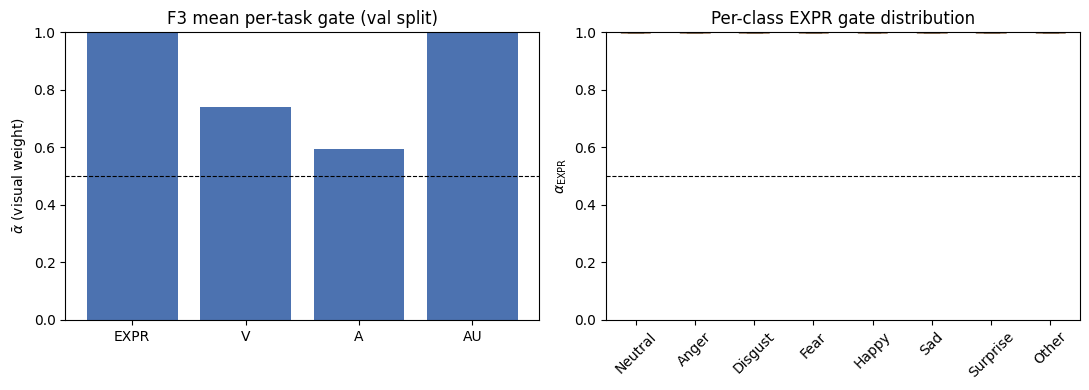

In [11]:
import matplotlib.pyplot as plt

EXPR_NAMES = ['Neutral', 'Anger', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Other']
TASK_NAMES = ['EXPR', 'V', 'A', 'AU']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(TASK_NAMES, alphas.mean(axis=0), color='#4c72b0')
axes[0].axhline(0.5, color='k', linestyle='--', linewidth=0.8)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel(r'$\bar\alpha$ (visual weight)')
axes[0].set_title('F3 mean per-task gate (val split)')

ex_mask = m_expr == 1
data_per_class = [alphas[ex_mask & (y_expr == c), 0] for c in range(8)]
axes[1].boxplot(data_per_class, labels=EXPR_NAMES, showfliers=False)
axes[1].axhline(0.5, color='k', linestyle='--', linewidth=0.8)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel(r'$\alpha_{\mathrm{EXPR}}$')
axes[1].set_title('Per-class EXPR gate distribution')
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()
fig_path = ABL / 'f3_gate_alpha.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'figure -> {fig_path}')
plt.show()

## 8. Aggregate summary table

Walks every per-variant `metrics.md` / `smoothing.json` produced above and writes a single Markdown table with the raw vs.\ smoothed numbers per ablation. Output: `results/aw2_stage3_ablations/summary.{md,json}`.

In [13]:
VARIANTS = [
    # (label, results dir relative to REPO/results/, config relative to REPO/configs/)
    ('visual_only (raw + smoothed)',                  'stage3_visual_only',          'stage3_visual_only.yaml'),
    ('audio_only',                                    'stage3_audio_only',           'stage3_audio_only.yaml'),
    ('F4 baseline (HuBERT, w=5, wd=1e-4, ep=15)',     'stage3_f4_xattn',             'stage3_f4_xattn.yaml'),
    ('F4 stronger WD (HuBERT, w=5, wd=1e-3, ep=3)',   'stage3_f4_xattn_wd1e3',       'stage3_f4_xattn_wd1e3.yaml'),
    ('F4 wav2vec 2.0 base',                           'stage3_f4_xattn_wav2vec',     'stage3_f4_xattn_wav2vec.yaml'),
    ('F4 window=1',                                   'stage3_f4_xattn_w1',          'stage3_f4_xattn_w1.yaml'),
    ('F4 window=3',                                   'stage3_f4_xattn_w3',          'stage3_f4_xattn_w3.yaml'),
    ('F4 window=10',                                  'stage3_f4_xattn_w10',         'stage3_f4_xattn_w10.yaml'),
    ('F4 seed=0',                                     'stage3_f4_xattn_seed0',       None),
    ('F4 seed=1',                                     'stage3_f4_xattn_seed1',       None),
    ('F4 seed=2',                                     'stage3_f4_xattn_seed2',       None),
    ('F4 MBF backbone',                               'stage3_f4_xattn_mbf',         'stage3_f4_xattn_mbf.yaml'),
    ('visual_only MBF (control)',                     'stage3_visual_only_mbf',      'stage3_visual_only_mbf.yaml'),
]

def _read_smoothing(results_dir):
    p = REPO / 'results' / results_dir / 'smoothing.json'
    if not p.exists():
        return None
    return json.loads(p.read_text(encoding='utf-8'))

rows = []
for label, rdir, _cfg in VARIANTS:
    s = _read_smoothing(rdir)
    if s is None:
        rows.append((label, rdir, None, None))
        continue
    rows.append((label, rdir, s['raw'], s['best']))

lines = ['# Aff-Wild2 Stage 3 — S7 ablation summary\n']
lines.append('Single seed (where applicable). Raw and best-smoothed numbers per ablation.')
lines.append('Bimodal gap rows compute raw and smoothed `(P_MTL@0.5 of variant) - (P_MTL@0.5 of visual-only baseline of the same backbone)`.\n')
lines.append('| variant | raw CCC_VA | raw F1_EXPR | raw F1_AU | raw P_MTL@0.5 | best (sigma, delta) | sm CCC_VA | sm F1_EXPR | sm P_MTL@0.5 | delta_smooth |')
lines.append('| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |')
for label, rdir, raw, best in rows:
    if raw is None:
        lines.append(f'| `{label}` | --- (not run) | | | | | | | | |')
        continue
    sigdel = f"({best['sigma']:g}, {best['delta']})"
    delta = best['P_MTL@0.5'] - raw['P_MTL@0.5']
    lines.append(
        f"| `{label}` | {raw['CCC_VA']:.4f} | {raw['F1_EXPR_macro']:.4f} | {raw['F1_AU@0.5']:.4f} | "
        f"{raw['P_MTL@0.5']:.4f} | {sigdel} | {best['CCC_VA']:.4f} | {best['F1_EXPR_macro']:.4f} | "
        f"{best['P_MTL@0.5']:.4f} | {delta:+.4f} |"
    )
summary_md = '\n'.join(lines) + '\n'
(ABL / 'summary.md').write_text(summary_md, encoding='utf-8')
(ABL / 'summary.json').write_text(json.dumps(
    [{'label': l, 'results_dir': r, 'raw': raw, 'best': best} for l, r, raw, best in rows],
    indent=2, default=float,
), encoding='utf-8')
print(summary_md)

# Aff-Wild2 Stage 3 — S7 ablation summary

Single seed (where applicable). Raw and best-smoothed numbers per ablation.
Bimodal gap rows compute raw and smoothed `(P_MTL@0.5 of variant) - (P_MTL@0.5 of visual-only baseline of the same backbone)`.

| variant | raw CCC_VA | raw F1_EXPR | raw F1_AU | raw P_MTL@0.5 | best (sigma, delta) | sm CCC_VA | sm F1_EXPR | sm P_MTL@0.5 | delta_smooth |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| `visual_only (raw + smoothed)` | 0.4313 | 0.3335 | 0.4792 | 1.2439 | (500, 10) | 0.4802 | 0.3624 | 1.3218 | +0.0779 |
| `audio_only` | --- (not run) | | | | | | | | |
| `F4 baseline (HuBERT, w=5, wd=1e-4, ep=15)` | 0.4787 | 0.3371 | 0.4831 | 1.2989 | (100000, 10) | 0.5021 | 0.3430 | 1.3283 | +0.0294 |
| `F4 stronger WD (HuBERT, w=5, wd=1e-3, ep=3)` | 0.4791 | 0.3373 | 0.4835 | 1.2999 | (100000, 10) | 0.5024 | 0.3434 | 1.3294 | +0.0295 |
| `F4 wav2vec 2.0 base` | 0.4436 | 0.3232 | 0.4857 | 1.2524 | (100000, 10) | 0.4630 | 0.3268 | 1.2755 | 

Drop the `summary.md` rows into the §6 Stage 3 ablations tables in `internship_report.tex` once each section finishes; the `tab:stage3aw2_smoothing` numbers in the report come from Section 1 of this notebook directly.